In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/house_prices.csv')
df.head()

,Unnamed: 0,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,purpose,bedrooms,date_added,agency,agent,Total_Area
0,0,237062,3325,https://www.zameen.com/Property/g_10_g_10_2_gr...,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,For Sale,2,2/4/2019,NaN,NaN,1089.004
1,1,346905,3236,https://www.zameen.com/Property/e_11_2_service...,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,For Sale,3,5/4/2019,NaN,NaN,15246.056
2,2,386513,764,https://www.zameen.com/Property/islamabad_g_15...,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,For Sale,5,7/17/2019,NaN,NaN,2178.008
3,3,656161,340,https://www.zameen.com/Property/islamabad_bani...,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,For Sale,4,4/5/2019,NaN,NaN,10890.000
4,4,841645,3226,https://www.zameen.com/Property/dha_valley_dha...,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,For Sale,3,7/10/2019,Easy Property,Muhammad Junaid Ceo Muhammad Shahid Director,2178.008


In [3]:
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 168446 entries, 0 to 168445
Data columns (total 18 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Unnamed: 0     168446 non-null  int64  
 1   property_id    168446 non-null  int64  
 2   location_id    168446 non-null  int64  
 3   page_url       168446 non-null  str    
 4   property_type  168446 non-null  str    
 5   price          168446 non-null  int64  
 6   location       168446 non-null  str    
 7   city           168446 non-null  str    
 8   province_name  168446 non-null  str    
 9   latitude       168446 non-null  float64
 10  longitude      168446 non-null  float64
 11  baths          168446 non-null  int64  
 12  purpose        168446 non-null  str    
 13  bedrooms       168446 non-null  int64  
 14  date_added     168446 non-null  str    
 15  agency         124375 non-null  str    
 16  agent          124374 non-null  str    
 17  Total_Area     168446 non-null  float64


(168446, 18)

## Problem Statement

Real estate pricing in Pakistan is often inconsistent and driven by informal negotiation rather than data. Buyers and sellers frequently lack a reliable way to estimate a fair market price for a property based on its actual features (location, size, type, amenities). This project builds a machine learning model that predicts house prices in Pakistan using property listings scraped from Zameen.com, helping buyers, sellers, and agents make more informed pricing decisions.

In [4]:
df = df.drop(columns=['Unnamed: 0', 'property_id', 'location_id', 'page_url', 'agency', 'agent', 'date_added'])
df.head()

,property_type,price,location,city,province_name,latitude,longitude,baths,purpose,bedrooms,Total_Area
0,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,For Sale,2,1089.004
1,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,For Sale,3,15246.056
2,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,For Sale,5,2178.008
3,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,For Sale,4,10890.000
4,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,For Sale,3,2178.008


In [5]:
df['purpose'].value_counts()

purpose
For Sale    120655
For Rent     47791
Name: count, dtype: int64

In [6]:
df = df[df['purpose'] == 'For Sale']
df = df.drop(columns=['purpose'])
df.shape

(120655, 10)

In [7]:
df.isnull().sum()
df.describe()

,price,latitude,longitude,baths,bedrooms,Total_Area
count,1.206550e+05,120655.000000,120655.000000,120655.000000,120655.000000,1.206550e+05
mean,2.476513e+07,29.434611,71.200581,3.085948,3.401384,1.432843e+04
std,3.959754e+07,3.679416,3.281108,2.560652,1.928359,1.018423e+06
min,0.000000e+00,24.749425,31.389173,0.000000,0.000000,0.000000e+00
25%,7.400000e+06,24.946375,67.129162,1.000000,2.000000,1.633506e+03
50%,1.350000e+07,31.429589,73.074160,3.000000,3.000000,3.811514e+03
75%,2.600000e+07,31.585176,74.256549,5.000000,5.000000,1.143454e+04
max,2.000000e+09,73.184088,74.564727,403.000000,27.000000,3.387988e+08


In [8]:
df = df[(df['price'] > 0) & (df['Total_Area'] > 0)]
df.shape

(120644, 10)

In [9]:
price_upper = df['price'].quantile(0.99)
area_upper = df['Total_Area'].quantile(0.99)

df = df[(df['price'] <= price_upper) & (df['Total_Area'] <= area_upper)]
df = df[(df['baths'] <= 20) & (df['bedrooms'] <= 15)]

df.shape

(118536, 10)

In [10]:
df[['price', 'Total_Area', 'baths', 'bedrooms']].describe()

,price,Total_Area,baths,bedrooms
count,1.185360e+05,118536.000000,118536.000000,118536.000000
mean,2.163924e+07,8325.566135,3.061931,3.373785
std,2.464982e+07,11424.432201,2.256595,1.888090
min,1.000000e+00,272.251000,0.000000,0.000000
25%,7.200000e+06,1633.506000,1.000000,2.000000
50%,1.350000e+07,3811.514000,3.000000,3.000000
75%,2.500000e+07,11434.542000,5.000000,5.000000
max,1.825000e+08,81675.000000,14.000000,15.000000


### Data Cleaning Approach

The raw dataset had 120,655 "for sale" listings, but contained clear data errors — zero prices, zero areas, and extreme outliers (e.g., area values in the hundreds of millions, and one listing with 403 bathrooms). These were cleaned by:
1. Removing rows with price or area equal to 0
2. Capping price and area at the 99th percentile to remove extreme outliers while preserving genuinely expensive/large properties
3. Capping bathrooms at 20 and bedrooms at 15, since higher values are almost certainly data entry errors

After cleaning, 118,536 rows remained (98.3% of the "for sale" data retained) — a strong balance between removing noise and preserving genuine data.

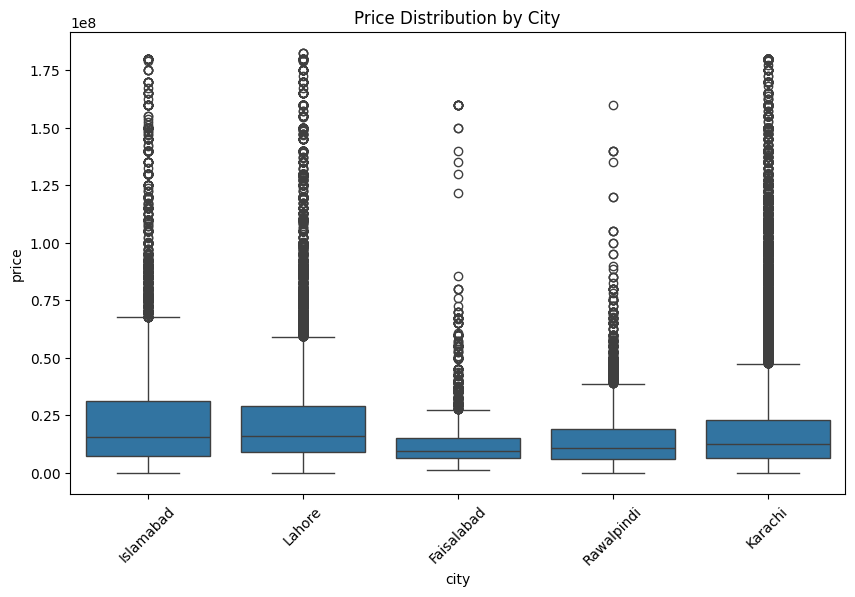

In [14]:
plt.figure(figsize=(10,6))
sns.boxplot(x='city', y='price', data=df)
plt.xticks(rotation=45)
plt.title('Price Distribution by City')
plt.show()

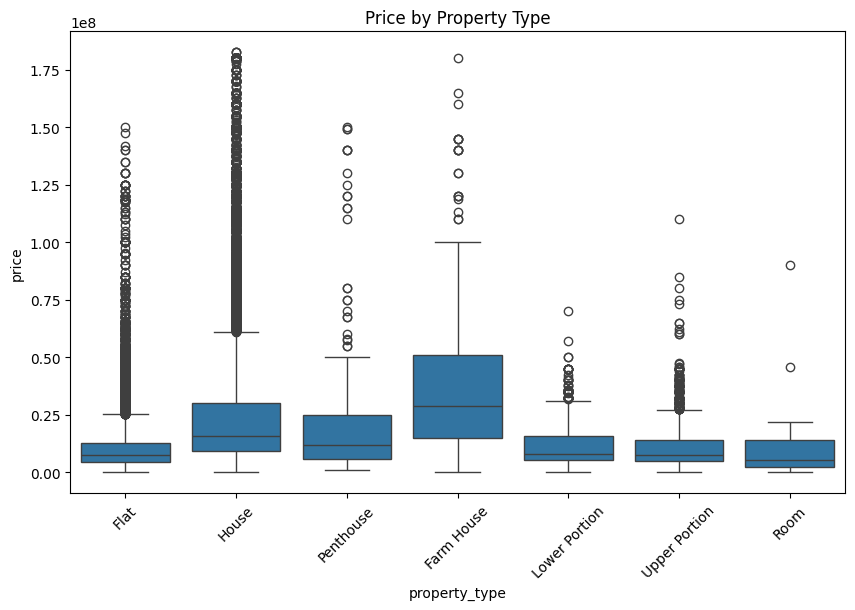

In [15]:
plt.figure(figsize=(10,6))
sns.boxplot(x='property_type', y='price', data=df)
plt.xticks(rotation=45)
plt.title('Price by Property Type')
plt.show()

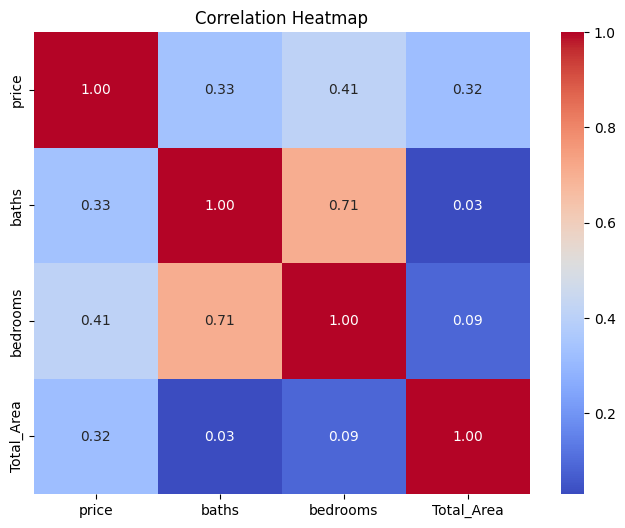

In [16]:
plt.figure(figsize=(8,6))
numeric_cols = ['price', 'baths', 'bedrooms', 'Total_Area']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### EDA Observations

- **Property Type**: "Farm House" and "House" have the highest median prices, while "Room" and "Lower Portion" are cheapest — makes sense given typical size and land value differences.
- **City**: Islamabad and Lahore have the highest median prices, while Faisalabad is generally cheapest — reflecting Pakistan's real estate demand concentration in major cities.
- **Correlation**: Interestingly, `Total_Area` has only a weak correlation with price (0.32) — weaker than `bedrooms` (0.41) and `baths` (0.33). This suggests location and property type may matter more than raw area alone, which is a key insight for feature engineering — location needs strong representation in the model.

In [17]:
print("Unique cities:", df['city'].nunique())
print("Unique locations:", df['location'].nunique())
print("Unique property types:", df['property_type'].nunique())

Unique cities: 5
Unique locations: 1444
Unique property types: 7


In [19]:
df['price_per_sqft'] = df['price'] / df['Total_Area']

top_locations = df['location'].value_counts().nlargest(20).index
df['location_grouped'] = df['location'].apply(lambda x: x if x in top_locations else 'Other')

In [20]:
model_df = df[['price', 'property_type', 'city', 'location_grouped', 'baths', 'bedrooms', 'Total_Area']]
model_df = pd.get_dummies(model_df, columns=['property_type', 'city', 'location_grouped'], drop_first=True)
model_df.head()

,price,baths,bedrooms,Total_Area,property_type_Flat,property_type_House,property_type_Lower Portion,property_type_Penthouse,property_type_Room,property_type_Upper Portion,...,location_grouped_Gulberg,location_grouped_Gulistan-e-Jauhar,location_grouped_Gulshan-e-Iqbal Town,location_grouped_Johar Town,location_grouped_Malir,location_grouped_Nazimabad,location_grouped_North Karachi,location_grouped_North Nazimabad,location_grouped_Other,location_grouped_Scheme 33
0,10000000,2,2,1089.004,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,6900000,3,3,15246.056,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,16500000,6,5,2178.008,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,43500000,4,4,10890.000,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,7000000,3,3,2178.008,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [21]:
from sklearn.model_selection import train_test_split

X = model_df.drop(columns=['price'])
y = model_df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results[name] = {'RMSE': rmse, 'R2': r2}
    print(f"{name} -> RMSE: {rmse:,.0f}, R2: {r2:.3f}")

Linear Regression -> RMSE: 18,334,088, R2: 0.451
Random Forest -> RMSE: 9,864,214, R2: 0.841
XGBoost -> RMSE: 9,718,241, R2: 0.846


### Model Comparison

| Model              | RMSE (PKR)  | R² Score |
|---------------------|-------------|----------|
| Linear Regression    | 18,334,088  | 0.451    |
| Random Forest         | 9,864,214   | 0.841    |
| XGBoost                | 9,718,241   | 0.846    |

XGBoost performed best, explaining ~85% of the variance in house prices. Linear Regression struggled significantly, confirming that house price relationships in this dataset are highly non-linear — location, property type, and size interact in complex ways that tree-based models capture much better than a straight-line fit.

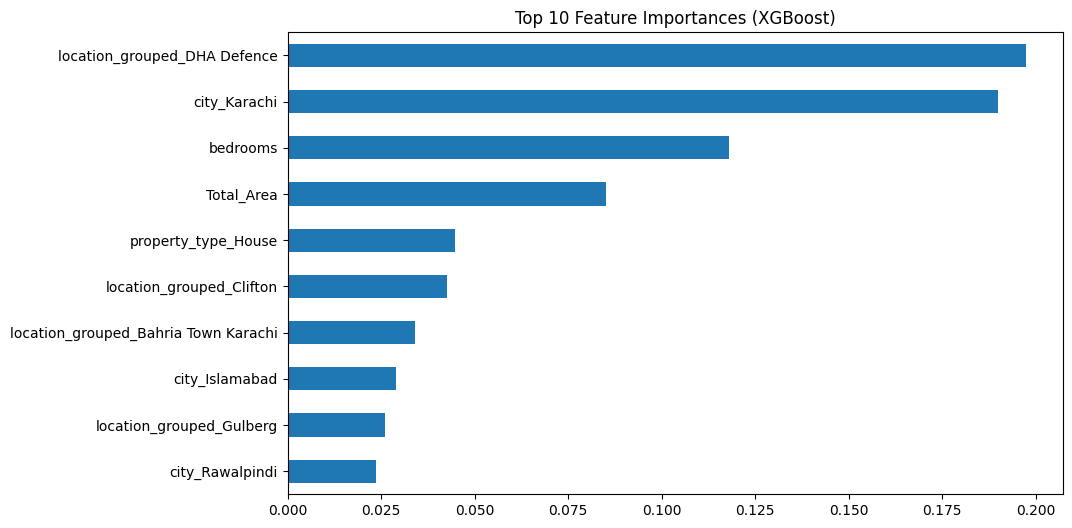

In [23]:
xgb_model = models['XGBoost']
importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
importances.plot(kind='barh')
plt.title('Top 10 Feature Importances (XGBoost)')
plt.gca().invert_yaxis()
plt.show()

In [24]:
import joblib

joblib.dump(xgb_model, 'house_price_model.pkl')
joblib.dump(X.columns.tolist(), 'model_columns.pkl')

['model_columns.pkl']

### Feature Importance Insight

Location dominates price prediction — being in **DHA Defence** or **Karachi** are the two strongest price drivers, even above property size (`Total_Area`) and `bedrooms`. This confirms a well-known real estate principle: "location, location, location." Interestingly, `Total_Area` ranks only 4th, reinforcing the earlier correlation finding — where a property is matters more than how big it is, in Pakistan's housing market.